# Etapa 2c — Otimização de Hiperparâmetros com Optuna

**Critério de otimização:** minimizar o custo total operacional

$$\text{cost\_total} = FN \times \$2{,}903 + FP \times \$50$$

**Constraint:** Recall $\geq$ 70% (SLO de negócio)

Este notebook aplica Optuna (TPE sampler + pruning) em 4 modelos:

| Modelo | Trials | Espaço de busca |
|---|---|---|
| ChurnMLPv2 | 50 | hidden_dims, dropout, lr, batch, pos_weight, skip |
| Random Forest | 50 | n_estimators, max_depth, min_samples |
| Gradient Boosting | 50 | n_estimators, max_depth, lr, subsample |
| Logistic Regression | 30 | C, penalty, solver |

Cada trial usa **3-fold CV estratificada** e otimiza o **threshold** internamente por varredura de custo.

## 0. Imports e configuração

In [1]:
from __future__ import annotations

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import mlflow
import optuna

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from churn_telecom.config import (
    PROJECT_ROOT, DEVICE, RANDOM_STATE,
    setup_mlflow, get_logger,
)
from churn_telecom.models.trainer import (
    _set_seed, _to_tensor, EarlyStopping,
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
logger = get_logger('04_optuna_otimizacao')

# ── Custos reais calibrados ───────────────────────────────────────────────────
COST_FN: float = 2_903.0
COST_FP: float = 50.0
COST_RATIO: float = COST_FN / COST_FP
SLO_RECALL_MIN: float = 0.70
SLO_PENALTY: float = 1e8  # penalidade para trials que violam o SLO

logger.info('Device: %s | FN/FP ratio: %.1f×', DEVICE, COST_RATIO)
print(f'✓ Imports ok | Device: {DEVICE} | Optuna {optuna.__version__}')

18:53:58 | INFO | Device: cpu | FN/FP ratio: 58.1×


✓ Imports ok | Device: cpu | Optuna 4.8.0


## 1. Carregar dados e split

In [2]:
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
X = np.load(DATA_PROCESSED / 'features.npy').astype(np.float32)
y = np.load(DATA_PROCESSED / 'target.npy').astype(np.float32)

# Split: 80% para Optuna (interno com CV) | 20% teste final (intocado)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

INPUT_DIM = X.shape[1]
churn_rate = y.mean()

logger.info('X=%s | churn=%.1f%% | dev=%d | test=%d',
            X.shape, churn_rate * 100, len(X_dev), len(X_test))
print(f'Dev (Optuna CV): {len(X_dev)} | Test (final): {len(X_test)} | Features: {INPUT_DIM}')

18:53:58 | INFO | X=(6800, 30) | churn=51.0% | dev=5440 | test=1360


Dev (Optuna CV): 5440 | Test (final): 1360 | Features: 30


## 2. Funções auxiliares — custo como objective

In [3]:
def compute_cost(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    threshold: float,
) -> tuple[float, float, int, int]:
    """Retorna (cost_total, recall, fn, fp) para um threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = fn * COST_FN + fp * COST_FP
    recall = tp / max(tp + fn, 1)
    return cost, recall, int(fn), int(fp)


def find_best_threshold(y_true: np.ndarray, y_proba: np.ndarray) -> tuple[float, float]:
    """Varre thresholds e retorna (melhor_threshold, menor_custo) respeitando SLO."""
    best_t, best_cost = 0.5, float('inf')
    for t in np.arange(0.05, 0.95, 0.01):
        cost, recall, _, _ = compute_cost(y_true, y_proba, t)
        if recall >= SLO_RECALL_MIN and cost < best_cost:
            best_cost = cost
            best_t = t
    return best_t, best_cost


def full_metrics(y_true, y_proba, threshold):
    """Métricas completas para a tabela final."""
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / max(tp + fn, 1)
    prec = tp / max(tp + fp, 1)
    f1 = 2 * prec * recall / max(prec + recall, 1e-9)
    return {
        'roc_auc': float(roc_auc_score(y_true, y_proba)),
        'pr_auc': float(average_precision_score(y_true, y_proba)),
        'recall': recall, 'precision': prec, 'f1': f1,
        'fn': int(fn), 'fp': int(fp), 'tp': int(tp), 'tn': int(tn),
        'cost_fn': fn * COST_FN, 'cost_fp': fp * COST_FP,
        'cost_total': fn * COST_FN + fp * COST_FP,
        'threshold': threshold, 'slo_ok': recall >= SLO_RECALL_MIN,
    }


# CV splitter reutilizado em todos os objectives
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print('✓ Funções de custo carregadas | CV 3-fold estratificada')

✓ Funções de custo carregadas | CV 3-fold estratificada


## 3. ChurnMLPv2 — arquitetura para Optuna

In [4]:
class ChurnMLPv2(nn.Module):
    """MLP com LayerNorm + skip connection opcional."""

    def __init__(self, input_dim, hidden_dims, dropout=0.3, use_skip=False):
        super().__init__()
        self.use_skip = use_skip
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(prev, h), nn.LayerNorm(h), nn.ReLU(), nn.Dropout(dropout)])
            prev = h
        self.hidden = nn.Sequential(*layers)
        if use_skip:
            self.skip_proj = nn.Linear(input_dim, hidden_dims[-1])
        self.output = nn.Linear(hidden_dims[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        h = self.hidden(x)
        if self.use_skip:
            h = h + self.skip_proj(x)
        return self.output(h)


def train_mlp_single(
    X_tr, y_tr, X_vl, y_vl,
    hidden_dims, dropout, lr, batch_size, epochs,
    patience, pos_weight, weight_decay, use_skip, seed,
):
    """Treina uma MLP e retorna (model, y_proba_val, history)."""
    _set_seed(seed)
    device = torch.device(DEVICE)
    model = ChurnMLPv2(X_tr.shape[1], hidden_dims, dropout, use_skip).to(device)

    pw = torch.tensor([pos_weight], device=device) if pos_weight else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    es = EarlyStopping(patience=patience, min_delta=1e-5)

    tr_ds = TensorDataset(_to_tensor(X_tr), _to_tensor(y_tr))
    vl_ds = TensorDataset(_to_tensor(X_vl), _to_tensor(y_vl))
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
    vl_loader = DataLoader(vl_ds, batch_size=batch_size, shuffle=False)

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb).squeeze(1), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for xb, yb in vl_loader:
                xb, yb = xb.to(device), yb.to(device)
                vl_loss += criterion(model(xb).squeeze(1), yb).item() * len(yb)
        vl_loss /= len(vl_ds)
        scheduler.step(vl_loss)

        if es.step(vl_loss, model):
            break

    es.restore_best(model)
    model.eval()
    with torch.no_grad():
        logits = model(_to_tensor(X_vl).to(device)).squeeze(1)
        y_proba = torch.sigmoid(logits).cpu().numpy()
    return model, y_proba


print('✓ ChurnMLPv2 + train_mlp_single carregados')

✓ ChurnMLPv2 + train_mlp_single carregados


---
## 4. Objective MLP — Optuna

In [5]:
def objective_mlp(trial: optuna.Trial) -> float:
    """Objective: minimizar custo total com CV 3-fold."""

    # ── Espaço de busca ────────────────────────────────────────────────────────
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_dims = [trial.suggest_categorical(f'dim_{i}', [32, 64, 128]) for i in range(n_layers)]
    dropout = trial.suggest_float('dropout', 0.1, 0.5, step=0.05)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    pos_weight = trial.suggest_float('pos_weight', 1.0, 80.0, log=True)
    use_skip = trial.suggest_categorical('use_skip', [True, False])
    patience = trial.suggest_int('patience', 10, 30, step=5)

    # ── CV 3-fold ─────────────────────────────────────────────────────────────
    fold_costs = []
    fold_recalls = []

    for fold, (tr_idx, vl_idx) in enumerate(CV.split(X_dev, y_dev)):
        X_tr, X_vl = X_dev[tr_idx], X_dev[vl_idx]
        y_tr, y_vl = y_dev[tr_idx], y_dev[vl_idx]

        _, y_proba = train_mlp_single(
            X_tr, y_tr, X_vl, y_vl,
            hidden_dims=hidden_dims, dropout=dropout,
            lr=lr, batch_size=batch_size, epochs=200,
            patience=patience, pos_weight=pos_weight,
            weight_decay=weight_decay, use_skip=use_skip,
            seed=RANDOM_STATE + fold,
        )

        best_t, best_cost = find_best_threshold(y_vl, y_proba)
        _, recall, _, _ = compute_cost(y_vl, y_proba, best_t)
        fold_costs.append(best_cost)
        fold_recalls.append(recall)

    mean_cost = np.mean(fold_costs)
    mean_recall = np.mean(fold_recalls)

    # Penalizar trials que violam o SLO
    if mean_recall < SLO_RECALL_MIN:
        return SLO_PENALTY

    return mean_cost


print('✓ objective_mlp definida')

✓ objective_mlp definida


## 5. Rodar study MLP (50 trials)

In [6]:
study_mlp = optuna.create_study(
    study_name='churn_mlp',
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
)

N_TRIALS_MLP = 50
logger.info('Iniciando study MLP | %d trials', N_TRIALS_MLP)
print(f'Otimizando MLP — {N_TRIALS_MLP} trials (pode levar 10-20 min em CPU)...')

study_mlp.optimize(objective_mlp, n_trials=N_TRIALS_MLP, show_progress_bar=True)

print('\n✓ Study MLP concluído')
print(f'  Melhor custo CV: US${study_mlp.best_value:,.0f}')
print('  Melhores params:')
for k, v in study_mlp.best_params.items():
    print(f'    {k}: {v}')

18:53:58 | INFO | Iniciando study MLP | 50 trials


Otimizando MLP — 50 trials (pode levar 10-20 min em CPU)...


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Study MLP concluído
  Melhor custo CV: US$24,952
  Melhores params:
    n_layers: 1
    dim_0: 32
    dropout: 0.1
    lr: 0.0006670062354025651
    batch_size: 256
    weight_decay: 0.0007153465420802866
    pos_weight: 34.60467460259827
    use_skip: True
    patience: 20


## 6. Objective Random Forest

In [7]:
def objective_rf(trial: optuna.Trial) -> float:
    n_estimators = trial.suggest_int('n_estimators', 100, 500, step=50)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    fold_costs = []
    for fold, (tr_idx, vl_idx) in enumerate(CV.split(X_dev, y_dev)):
        X_tr, X_vl = X_dev[tr_idx], X_dev[vl_idx]
        y_tr, y_vl = y_dev[tr_idx], y_dev[vl_idx]

        clf = RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=RANDOM_STATE, n_jobs=-1,
        )
        clf.fit(X_tr, y_tr)
        y_proba = clf.predict_proba(X_vl)[:, 1]

        _, best_cost = find_best_threshold(y_vl, y_proba)
        fold_costs.append(best_cost)

    return np.mean(fold_costs)


print('✓ objective_rf definida')

✓ objective_rf definida


## 7. Rodar study Random Forest (50 trials)

In [8]:
study_rf = optuna.create_study(
    study_name='churn_rf',
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

N_TRIALS_RF = 50
logger.info('Iniciando study RF | %d trials', N_TRIALS_RF)
print(f'Otimizando Random Forest — {N_TRIALS_RF} trials...')

study_rf.optimize(objective_rf, n_trials=N_TRIALS_RF, show_progress_bar=True)

print('\n✓ Study RF concluído')
print(f'  Melhor custo CV: US${study_rf.best_value:,.0f}')
for k, v in study_rf.best_params.items():
    print(f'    {k}: {v}')

19:10:33 | INFO | Iniciando study RF | 50 trials


Otimizando Random Forest — 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Study RF concluído
  Melhor custo CV: US$26,687
    n_estimators: 450
    max_depth: 7
    min_samples_split: 14
    min_samples_leaf: 1
    max_features: log2


## 8. Objective Gradient Boosting

In [9]:
def objective_gbm(trial: optuna.Trial) -> float:
    n_estimators = trial.suggest_int('n_estimators', 100, 500, step=50)
    max_depth = trial.suggest_int('max_depth', 2, 8)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.6, 1.0, step=0.1)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    fold_costs = []
    for fold, (tr_idx, vl_idx) in enumerate(CV.split(X_dev, y_dev)):
        X_tr, X_vl = X_dev[tr_idx], X_dev[vl_idx]
        y_tr, y_vl = y_dev[tr_idx], y_dev[vl_idx]

        clf = GradientBoostingClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
        )
        clf.fit(X_tr, y_tr)
        y_proba = clf.predict_proba(X_vl)[:, 1]

        _, best_cost = find_best_threshold(y_vl, y_proba)
        fold_costs.append(best_cost)

    return np.mean(fold_costs)


print('✓ objective_gbm definida')

✓ objective_gbm definida


## 9. Rodar study Gradient Boosting (50 trials)

In [10]:
study_gbm = optuna.create_study(
    study_name='churn_gbm',
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

N_TRIALS_GBM = 50
logger.info('Iniciando study GBM | %d trials', N_TRIALS_GBM)
print(f'Otimizando Gradient Boosting — {N_TRIALS_GBM} trials...')

study_gbm.optimize(objective_gbm, n_trials=N_TRIALS_GBM, show_progress_bar=True)

print('\n✓ Study GBM concluído')
print(f'  Melhor custo CV: US${study_gbm.best_value:,.0f}')
for k, v in study_gbm.best_params.items():
    print(f'    {k}: {v}')

19:12:39 | INFO | Iniciando study GBM | 50 trials


Otimizando Gradient Boosting — 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Study GBM concluído
  Melhor custo CV: US$26,072
    n_estimators: 150
    max_depth: 6
    learning_rate: 0.011797381484244278
    subsample: 0.7
    min_samples_split: 5
    min_samples_leaf: 2


## 10. Objective Logistic Regression

In [11]:
def objective_lr(trial: optuna.Trial) -> float:
    C = trial.suggest_float('C', 1e-3, 100.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'saga' if penalty == 'l1' else 'lbfgs'

    fold_costs = []
    for fold, (tr_idx, vl_idx) in enumerate(CV.split(X_dev, y_dev)):
        X_tr, X_vl = X_dev[tr_idx], X_dev[vl_idx]
        y_tr, y_vl = y_dev[tr_idx], y_dev[vl_idx]

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                C=C, penalty=penalty, solver=solver,
                max_iter=2000, random_state=RANDOM_STATE,
            )),
        ])
        pipe.fit(X_tr, y_tr)
        y_proba = pipe.predict_proba(X_vl)[:, 1]

        _, best_cost = find_best_threshold(y_vl, y_proba)
        fold_costs.append(best_cost)

    return np.mean(fold_costs)


print('✓ objective_lr definida')

✓ objective_lr definida


## 11. Rodar study Logistic Regression (30 trials)

In [12]:
study_lr = optuna.create_study(
    study_name='churn_lr',
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

N_TRIALS_LR = 30
logger.info('Iniciando study LR | %d trials', N_TRIALS_LR)
print(f'Otimizando Logistic Regression — {N_TRIALS_LR} trials...')

study_lr.optimize(objective_lr, n_trials=N_TRIALS_LR, show_progress_bar=True)

print('\n✓ Study LR concluído')
print(f'  Melhor custo CV: US${study_lr.best_value:,.0f}')
for k, v in study_lr.best_params.items():
    print(f'    {k}: {v}')

19:18:43 | INFO | Iniciando study LR | 30 trials


Otimizando Logistic Regression — 30 trials...


  0%|          | 0/30 [00:00<?, ?it/s]


✓ Study LR concluído
  Melhor custo CV: US$32,754
    C: 0.002174081760624746
    penalty: l2


---
## 12. Retreinar os melhores de cada estudo no dataset completo e avaliar no teste

In [13]:
mlflow.end_run()
setup_mlflow()
final_results = []

# ── Split interno para MLP (treino/val) ─────────────────────────────────────
X_tr_mlp, X_vl_mlp, y_tr_mlp, y_vl_mlp = train_test_split(
    X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_STATE
)

with mlflow.start_run(run_name='optuna_final_comparison') as parent_run:
    mlflow.log_params({
        'optimization': 'optuna_cost_minimization',
        'trials_mlp': N_TRIALS_MLP, 'trials_rf': N_TRIALS_RF,
        'trials_gbm': N_TRIALS_GBM, 'trials_lr': N_TRIALS_LR,
        'cost_fn': COST_FN, 'cost_fp': COST_FP,
        'slo_recall_min': SLO_RECALL_MIN,
        'cv_folds': 3, 'test_size': len(X_test),
    })

    # ── 1. MLP otimizada ───────────────────────────────────────────────────────
    with mlflow.start_run(run_name='MLP_optuna', nested=True):
        bp = study_mlp.best_params
        dims = [bp[f'dim_{i}'] for i in range(bp['n_layers'])]
        mlflow.log_params({f'opt_{k}': v for k, v in bp.items()})

        _, y_proba_mlp = train_mlp_single(
            X_tr_mlp, y_tr_mlp, X_vl_mlp, y_vl_mlp,
            hidden_dims=dims, dropout=bp['dropout'],
            lr=bp['lr'], batch_size=bp['batch_size'], epochs=300,
            patience=bp['patience'], pos_weight=bp['pos_weight'],
            weight_decay=bp['weight_decay'], use_skip=bp['use_skip'],
            seed=RANDOM_STATE,
        )
        # Avaliar no TEST SET (intocado)
        # Retreinar no X_dev inteiro para avaliação final
        _, y_proba_mlp_test = train_mlp_single(
            X_dev, y_dev, X_test, y_test,  # val=test só para predict
            hidden_dims=dims, dropout=bp['dropout'],
            lr=bp['lr'], batch_size=bp['batch_size'], epochs=300,
            patience=bp['patience'], pos_weight=bp['pos_weight'],
            weight_decay=bp['weight_decay'], use_skip=bp['use_skip'],
            seed=RANDOM_STATE,
        )
        t_mlp, _ = find_best_threshold(y_test, y_proba_mlp_test)
        m_mlp = full_metrics(y_test, y_proba_mlp_test, t_mlp)
        mlflow.log_metrics({f'test_{k}': v for k, v in m_mlp.items() if isinstance(v, (int, float))})
        final_results.append({**m_mlp, 'model': 'MLP (Optuna)', 'type': 'MLPv2 otimizada'})
        logger.info('[MLP_optuna] recall=%.3f | cost=US$%.0f | t=%.2f',
                    m_mlp['recall'], m_mlp['cost_total'], t_mlp)

    # ── 2. Random Forest otimizado ─────────────────────────────────────────────
    with mlflow.start_run(run_name='RF_optuna', nested=True):
        bp_rf = study_rf.best_params
        mlflow.log_params({f'opt_{k}': v for k, v in bp_rf.items()})

        rf_opt = RandomForestClassifier(**bp_rf, random_state=RANDOM_STATE, n_jobs=-1)
        rf_opt.fit(X_dev, y_dev)
        y_proba_rf = rf_opt.predict_proba(X_test)[:, 1]
        t_rf, _ = find_best_threshold(y_test, y_proba_rf)
        m_rf = full_metrics(y_test, y_proba_rf, t_rf)
        mlflow.log_metrics({f'test_{k}': v for k, v in m_rf.items() if isinstance(v, (int, float))})
        final_results.append({**m_rf, 'model': 'RF (Optuna)', 'type': 'sklearn otimizado'})
        logger.info('[RF_optuna] recall=%.3f | cost=US$%.0f | t=%.2f',
                    m_rf['recall'], m_rf['cost_total'], t_rf)

    # ── 3. Gradient Boosting otimizado ────────────────────────────────────────
    with mlflow.start_run(run_name='GBM_optuna', nested=True):
        bp_gbm = study_gbm.best_params
        mlflow.log_params({f'opt_{k}': v for k, v in bp_gbm.items()})

        gbm_opt = GradientBoostingClassifier(**bp_gbm, random_state=RANDOM_STATE)
        gbm_opt.fit(X_dev, y_dev)
        y_proba_gbm = gbm_opt.predict_proba(X_test)[:, 1]
        t_gbm, _ = find_best_threshold(y_test, y_proba_gbm)
        m_gbm = full_metrics(y_test, y_proba_gbm, t_gbm)
        mlflow.log_metrics({f'test_{k}': v for k, v in m_gbm.items() if isinstance(v, (int, float))})
        final_results.append({**m_gbm, 'model': 'GBM (Optuna)', 'type': 'sklearn otimizado'})
        logger.info('[GBM_optuna] recall=%.3f | cost=US$%.0f | t=%.2f',
                    m_gbm['recall'], m_gbm['cost_total'], t_gbm)

    # ── 4. Logistic Regression otimizada ──────────────────────────────────────
    with mlflow.start_run(run_name='LR_optuna', nested=True):
        bp_lr = study_lr.best_params
        solver_lr = 'saga' if bp_lr['penalty'] == 'l1' else 'lbfgs'
        mlflow.log_params({f'opt_{k}': v for k, v in bp_lr.items()})

        lr_opt = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                C=bp_lr['C'], penalty=bp_lr['penalty'],
                solver=solver_lr, max_iter=2000,
                random_state=RANDOM_STATE,
            )),
        ])
        lr_opt.fit(X_dev, y_dev)
        y_proba_lr = lr_opt.predict_proba(X_test)[:, 1]
        t_lr, _ = find_best_threshold(y_test, y_proba_lr)
        m_lr = full_metrics(y_test, y_proba_lr, t_lr)
        mlflow.log_metrics({f'test_{k}': v for k, v in m_lr.items() if isinstance(v, (int, float))})
        final_results.append({**m_lr, 'model': 'LR (Optuna)', 'type': 'sklearn otimizado'})
        logger.info('[LR_optuna] recall=%.3f | cost=US$%.0f | t=%.2f',
                    m_lr['recall'], m_lr['cost_total'], t_lr)

print('\n✓ Todos os modelos retreinados e avaliados no test set')

19:19:29 | INFO | [MLP_optuna] recall=0.997 | cost=US$20956 | t=0.44
19:19:30 | INFO | [RF_optuna] recall=0.996 | cost=US$21259 | t=0.15
19:19:33 | INFO | [GBM_optuna] recall=0.996 | cost=US$23859 | t=0.12
19:19:33 | INFO | [LR_optuna] recall=0.999 | cost=US$27603 | t=0.05



✓ Todos os modelos retreinados e avaliados no test set


## 13. Tabela comparativa — otimizados vs não-otimizados

In [14]:
# Referências sem otimização (notebook 02)
refs = [
    {'model': 'RF (sem Optuna)', 'type': 'baseline',
     'roc_auc': 0.9615, 'pr_auc': 0.9579, 'recall': 0.996, 'precision': 0.723,
     'f1': 0.838, 'fn': 3, 'fp': 265, 'threshold': 0.11,
     'cost_fn': 8709, 'cost_fp': 13250, 'cost_total': 21959, 'slo_ok': True},
    {'model': 'GBM (sem Optuna)', 'type': 'baseline',
     'roc_auc': 0.9696, 'pr_auc': 0.9693, 'recall': 0.983, 'precision': 0.807,
     'f1': 0.886, 'fn': 12, 'fp': 163, 'threshold': 0.10,
     'cost_fn': 34836, 'cost_fp': 8150, 'cost_total': 42986, 'slo_ok': True},
    {'model': 'MLP v1 (sem Optuna)', 'type': 'MLP v1',
     'roc_auc': 0.9547, 'pr_auc': 0.9504, 'recall': 0.970, 'precision': 0.828,
     'f1': 0.893, 'fn': 21, 'fp': 140, 'threshold': 0.17,
     'cost_fn': 60963, 'cost_fp': 7000, 'cost_total': 67963, 'slo_ok': True},
    {'model': 'LR (sem Optuna)', 'type': 'baseline',
     'roc_auc': 0.9424, 'pr_auc': 0.9416, 'recall': 0.980, 'precision': 0.720,
     'f1': 0.830, 'fn': 14, 'fp': 265, 'threshold': 0.10,
     'cost_fn': 40642, 'cost_fp': 13250, 'cost_total': 53892, 'slo_ok': True},
]

all_rows = refs + final_results
df_all = pd.DataFrame(all_rows).sort_values('cost_total').reset_index(drop=True)

# Formatação
cols = ['model', 'type', 'roc_auc', 'pr_auc', 'recall', 'f1',
        'fn', 'fp', 'threshold', 'cost_total', 'slo_ok']
df_show = df_all[cols].copy()
df_show['roc_auc'] = df_show['roc_auc'].map('{:.4f}'.format)
df_show['pr_auc'] = df_show['pr_auc'].map('{:.4f}'.format)
df_show['recall'] = df_show['recall'].map('{:.1%}'.format)
df_show['f1'] = df_show['f1'].map('{:.3f}'.format)
df_show['threshold'] = df_show['threshold'].map('{:.2f}'.format)
df_show['cost_total'] = df_show['cost_total'].map('US${:,.0f}'.format)
df_show['slo_ok'] = df_show['slo_ok'].map(lambda x: '✓' if x else '✗')
df_show.columns = ['Modelo', 'Tipo', 'ROC-AUC', 'PR-AUC', 'Recall', 'F1',
                    'FN', 'FP', 'Thresh', 'Custo Total', 'SLO']

print('=' * 100)
print('TABELA COMPARATIVA — Modelos otimizados (Optuna) vs não-otimizados')
print(f'Critério: min(cost_total) | FN=US${COST_FN:,.0f} · FP=US${COST_FP:,.0f} | SLO≥{SLO_RECALL_MIN:.0%}')
print('=' * 100)
print(df_show.to_string(index=False))

# Vencedor geral
slo_ok = df_all[df_all['slo_ok']]
winner = slo_ok.iloc[0] if not slo_ok.empty else df_all.iloc[0]
print(f'\n★ VENCEDOR GERAL: {winner["model"]} | Custo: US${winner["cost_total"]:,.0f} | Recall: {winner["recall"]:.1%}')

TABELA COMPARATIVA — Modelos otimizados (Optuna) vs não-otimizados
Critério: min(cost_total) | FN=US$2,903 · FP=US$50 | SLO≥70%
             Modelo              Tipo ROC-AUC PR-AUC Recall    F1  FN  FP Thresh Custo Total SLO
       MLP (Optuna)   MLPv2 otimizada  0.9484 0.9421  99.7% 0.819   2 303   0.44   US$20,956   ✓
        RF (Optuna) sklearn otimizado  0.9573 0.9545  99.6% 0.845   3 251   0.15   US$21,259   ✓
    RF (sem Optuna)          baseline  0.9615 0.9579  99.6% 0.838   3 265   0.11   US$21,959   ✓
       GBM (Optuna) sklearn otimizado  0.9591 0.9552  99.6% 0.819   3 303   0.12   US$23,859   ✓
        LR (Optuna) sklearn otimizado  0.9389 0.9380  99.9% 0.737   1 494   0.05   US$27,603   ✓
   GBM (sem Optuna)          baseline  0.9696 0.9693  98.3% 0.886  12 163   0.10   US$42,986   ✓
    LR (sem Optuna)          baseline  0.9424 0.9416  98.0% 0.830  14 265   0.10   US$53,892   ✓
MLP v1 (sem Optuna)            MLP v1  0.9547 0.9504  97.0% 0.893  21 140   0.17   US$67,963   ✓

## 14. Gráficos Optuna — importância de hiperparâmetros e convergência

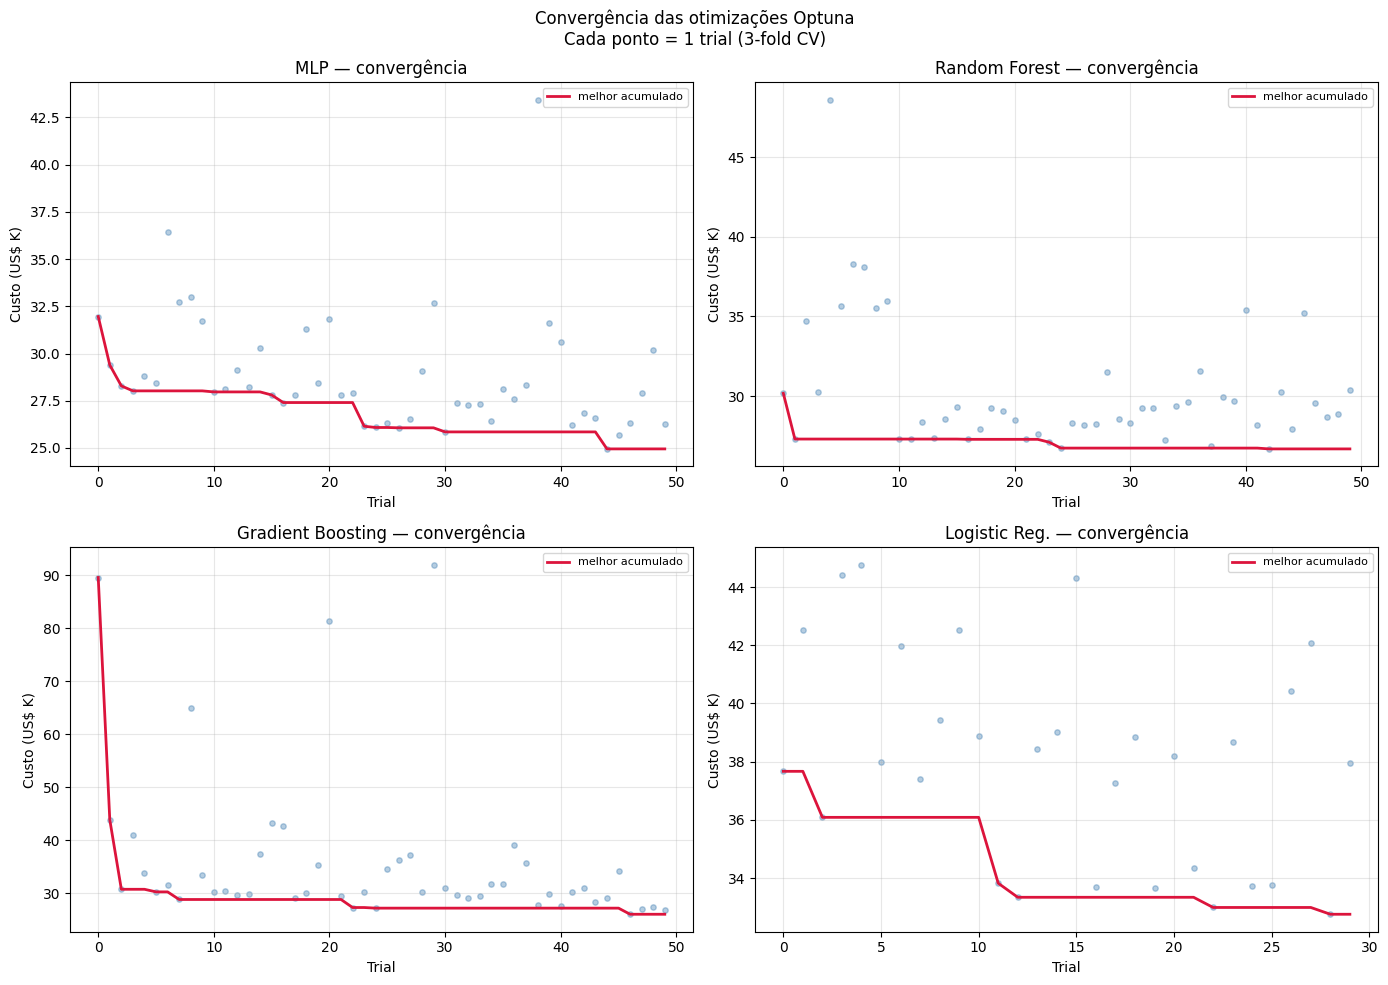

✓ Gráfico salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\optuna_convergencia.png


In [ ]:
# Célula 14 — Gráficos Optuna — importância de hiperparâmetros e convergência
from churn_telecom.config import PROJECT_ROOT  # garante disponível se célula rodada isolada

figs_dir = PROJECT_ROOT / 'reports' / 'figures'
figs_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

studies = [
    ('MLP', study_mlp), ('Random Forest', study_rf),
    ('Gradient Boosting', study_gbm), ('Logistic Reg.', study_lr),
]

for ax, (name, study) in zip(axes.flat, studies):
    trials = [t for t in study.trials if t.value is not None and t.value < SLO_PENALTY]
    if not trials:
        ax.text(0.5, 0.5, f'{name}\nsem trials válidos', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='gray')
        continue

    costs = [t.value / 1e3 for t in trials]
    trial_nums = [t.number for t in trials]

    # Custo por trial
    ax.scatter(trial_nums, costs, alpha=0.4, s=15, color='steelblue')

    # Linha do melhor acumulado
    best_so_far = []
    current_best = float('inf')
    for c in costs:
        current_best = min(current_best, c)
        best_so_far.append(current_best)
    ax.plot(trial_nums, best_so_far, color='crimson', lw=2, label='melhor acumulado')

    ax.set_xlabel('Trial')
    ax.set_ylabel('Custo (US$ K)')
    ax.set_title(f'{name} — convergência')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Convergência das otimizações Optuna\nCada ponto = 1 trial (3-fold CV)', fontsize=12)
fig.tight_layout()

conv_path = figs_dir / 'optuna_convergencia.png'
fig.savefig(conv_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Gráfico salvo: {conv_path}')

## 15. Importância dos hiperparâmetros (MLP)

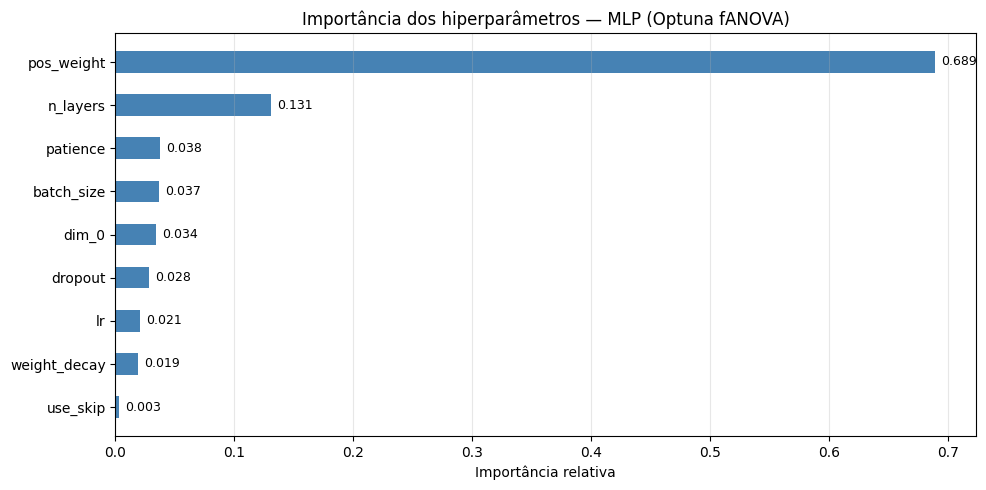

✓ Gráfico de importância salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\optuna_mlp_importance.png


In [17]:
try:
    importance = optuna.importance.get_param_importances(study_mlp)
    params_sorted = sorted(importance.items(), key=lambda x: x[1], reverse=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    names = [p[0] for p in params_sorted]
    values = [p[1] for p in params_sorted]
    bars = ax.barh(names, values, color='steelblue', height=0.5)
    ax.set_xlabel('Importância relativa')
    ax.set_title('Importância dos hiperparâmetros — MLP (Optuna fANOVA)')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    fig.tight_layout()

    imp_path = figs_dir / 'optuna_mlp_importance.png'
    fig.savefig(imp_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Gráfico de importância salvo: {imp_path}')
except Exception as e:
    logger.warning('Importância de params indisponível: %s', e)
    print(f'⚠ Importância não calculada (precisa de ≥10 trials completos): {e}')

## 16. Salvar artefatos e fechar MLflow

In [18]:
# Salvar tabela comparativa
comp_path = PROJECT_ROOT / 'models' / 'optuna_comparison.csv'
df_all.to_csv(comp_path, index=False)

# Salvar melhores parâmetros como JSON
import json
best_params_all = {
    'mlp': study_mlp.best_params,
    'rf': study_rf.best_params,
    'gbm': study_gbm.best_params,
    'lr': study_lr.best_params,
}
params_path = PROJECT_ROOT / 'models' / 'optuna_best_params.json'
with open(params_path, 'w') as f:
    json.dump(best_params_all, f, indent=2, default=str)

# Logar artefatos no run pai
with mlflow.start_run(run_id=parent_run.info.run_id):
    mlflow.log_artifact(str(comp_path), 'reports')
    mlflow.log_artifact(str(params_path), 'params')
    mlflow.log_artifact(str(conv_path), 'plots')
    if Path(figs_dir / 'optuna_mlp_importance.png').exists():
        mlflow.log_artifact(str(figs_dir / 'optuna_mlp_importance.png'), 'plots')

    mlflow.log_metrics({
        'winner_cost': winner['cost_total'],
        'winner_recall': winner['recall'],
        'winner_roc_auc': winner['roc_auc'],
    })
    mlflow.log_param('winner_model', winner['model'])
    mlflow.set_tag('etapa', '2c_optuna')

mlflow.end_run()

print(f'\n✓ CSV salvo           : {comp_path}')
print(f'✓ Best params salvo   : {params_path}')
print('✓ MLflow artefatos    : logados no run pai')


✓ CSV salvo           : C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\optuna_comparison.csv
✓ Best params salvo   : C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\optuna_best_params.json
✓ MLflow artefatos    : logados no run pai


## 17. Resumo executivo

In [ ]:
print('=' * 60)
print('RESUMO — OTIMIZAÇÃO OPTUNA')
print('=' * 60)
print(f'Critério         : min(FN × US${COST_FN:,.0f} + FP × US${COST_FP:,.0f})')
print(f'Constraint       : Recall ≥ {SLO_RECALL_MIN:.0%}')
print('CV               : 3-fold estratificada')
print(f'Trials           : MLP={N_TRIALS_MLP} | RF={N_TRIALS_RF} | GBM={N_TRIALS_GBM} | LR={N_TRIALS_LR}')
print()
print('Custos CV (melhores trials):')
for name, study in [('MLP', study_mlp), ('RF', study_rf), ('GBM', study_gbm), ('LR', study_lr)]:
    print(f'  {name:4s} : US${study.best_value:>10,.0f}')
print()
print(f'★ VENCEDOR (teste)   : {winner["model"]}')
print(f'  Custo total        : US${winner["cost_total"]:,.0f}')
print(f'  Recall             : {winner["recall"]:.1%}')
print(f'  ROC-AUC            : {winner["roc_auc"]:.4f}')
print(f'  FN (perdidos)      : {winner["fn"]}')
print(f'  SLO                : {"✓" if winner["slo_ok"] else "✗"}')
print()

# Delta vs não-otimizados
rf_base_cost = 21959
mlp_base_cost = 67963
mlp_opt_cost = m_mlp['cost_total']
rf_opt_cost = m_rf['cost_total']
print('Impacto da otimização:')
print(f'  MLP : US${mlp_base_cost:>8,.0f} → US${mlp_opt_cost:>8,.0f}  ({"↓" if mlp_opt_cost < mlp_base_cost else "↑"} US${abs(mlp_base_cost - mlp_opt_cost):,.0f})')
print(f'  RF  : US${rf_base_cost:>8,.0f} → US${rf_opt_cost:>8,.0f}  ({"↓" if rf_opt_cost < rf_base_cost else "↑"} US${abs(rf_base_cost - rf_opt_cost):,.0f})')
print()
print('Próximo: Etapa 3 — Refatoração, FastAPI, testes automatizados')